# Welcome to the `scatterscale` demo!

`scatterscale` is a package that can help you automatically choose the best normalizing scale for the colorbar that represents the third dimension of a scatterplot. Out of the native matplotlib.pyplot colorbar scaling options, 'scatterscale' chooses the one which shows the greatest contrast. In order to `scatterscale` to produce the best visual contrast, the colormap used must be perceptually uniform. We recommend using either `matplotlib`'s native perceptually uniform colormaps (viridis, plasma, inferno, magma, and cividis), or one of the many perceptually uniform colormaps available in the `cmasher` package.

This notebook requires you to pip install `scatterscale` before running it.

In [6]:
# some required import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scatterscale.outliers import handle_outliers
from scatterscale.choose_scaler import get_scatterscale

In this tutorial, we will represent data from the JWST Advanced Deep Extragalactic Survey (JADES, Eisenstein et al. 2026) Data Release 5 Photometric Catalog (Robertson et al. 2026). The required data file is provided alongside this notebook.

In [7]:
# fetch the demo data
data = pd.read_csv('jades_dr5_demo_data.csv')

In [8]:
data

,ID,F090W_KRON,F182M_KRON,F200W_KRON,F444W_KRON,photoz
0,490,44.891501,145.712765,72.365925,116.064542,2.80
1,519,45.079392,33.500378,43.180997,25.601965,0.76
2,522,-26.214179,30.203677,16.456006,30.149901,3.49
3,549,105.312790,138.397255,104.310861,89.744492,2.42
4,550,47.483395,75.022954,51.581375,28.120277,0.72
...,...,...,...,...,...,...
89725,3301718,-2.387266,4.853579,1.150072,26.270901,8.61
89726,3301754,18.730689,-40.162270,4.768035,41.189591,4.99
89727,3301987,-23.492848,-0.999764,4.515437,33.786540,4.22
89728,3302027,9.594798,10.986778,10.878755,20.080720,17.30


For each JADES galaxy, we want to plot its measured fluxes in two filters against each other, and color each datapoint by its flux measurement in a third filter.

In [16]:
def comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_data_key, xaxis_data_key, yaxis_data_key):
    """
    """

    fig, ax = plt.subplots(1,2, figsize=(10, 4))
    plt.style.use("dark_background")

    # without any scaling
    plot0 = ax[0].scatter(xaxis_data, yaxis_data, c=colorbar_data, norm=colors.NoNorm(np.nanmin(colorbar_data), np.nanmax(colorbar_data)), cmap="viridis", alpha=0.3, s=2)
    ax[0].set_title("No scaling")
    ax[0].set_xlabel(f"{xaxis_data_key}")
    ax[0].set_ylabel(f"{yaxis_data_key}")
    ax[0].set_xscale("log")
    ax[0].set_yscale("log")
    colorbar0 = fig.colorbar(plot0, ax=ax[0], label=colorbar_data_key)
    colorbar0.solids.set(alpha=1)

    ## use scatterscale to get the best normalization for the colorbar
    colorbar_norm = get_scatterscale(colorbar_data)

    # with scatterscale's optimal scaling
    plot1 = ax[1].scatter(xaxis_data, yaxis_data, c=colorbar_data, norm=colorbar_norm, cmap="viridis", alpha=0.3, s=2)
    ax[1].set_title("With scatterscale scaling")
    ax[1].set_xlabel(f"{xaxis_data_key}")
    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    colorbar1 = fig.colorbar(plot1, ax=ax[1], label=colorbar_data_key)
    colorbar1.solids.set(alpha=1)

    plt.tight_layout()
    plt.show()

    return

### demos

Best scaling: SymLog (linthresh=0.1)


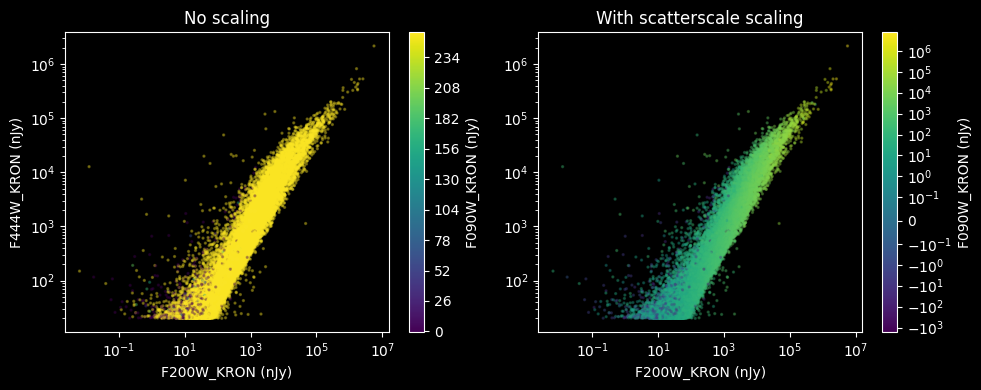

In [17]:
colorbar_data, colorbar_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
xaxis_data, xaxis_key = data["F200W_KRON"].values, "F200W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

Best scaling: SymLog (linthresh=0.1)


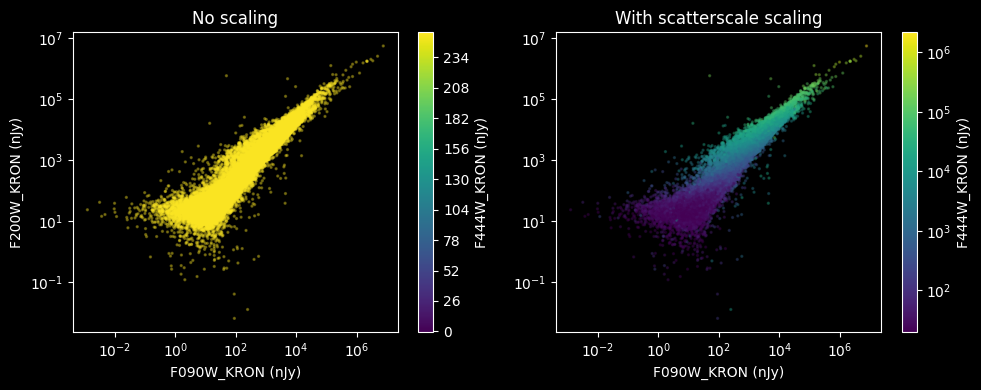

In [20]:
colorbar_data, colorbar_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F200W_KRON"].values, "F200W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

Best scaling: No normalization


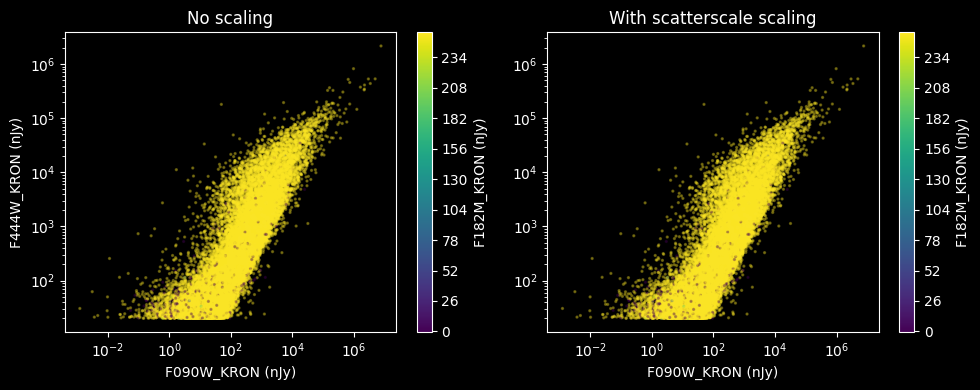

In [18]:
colorbar_data, colorbar_key = data["F182M_KRON"].values, "F182M_KRON (nJy)"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

Best scaling: Log


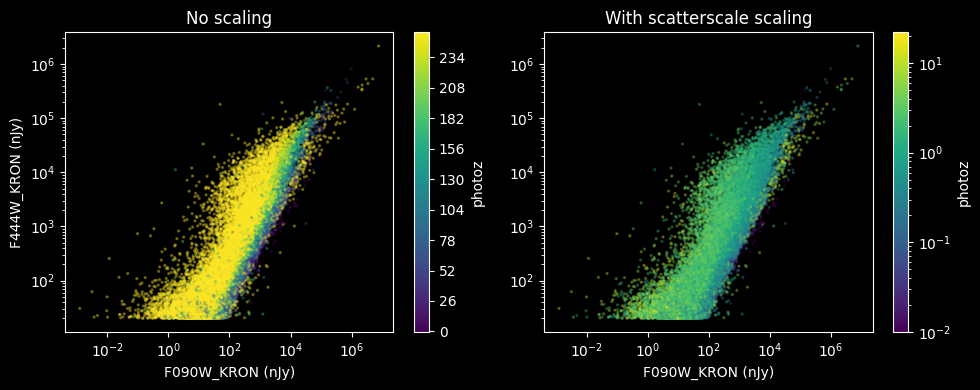

In [19]:
colorbar_data, colorbar_key = data["photoz"].values, "photoz"
xaxis_data, xaxis_key = data["F090W_KRON"].values, "F090W_KRON (nJy)"
yaxis_data, yaxis_key = data["F444W_KRON"].values, "F444W_KRON (nJy)"

comparison_plot(colorbar_data, xaxis_data, yaxis_data, colorbar_key, xaxis_key, yaxis_key)

## Handling outliers

In some cases, you may want to "handle" outlier values in the third flux measurement which would significantly disrupt the visual contrast we're seeking. The handle_outliers function allows you to either mask out outlier values completely, or to reassign them to value of the boundary above which they are considered an outlier. The default handling is to mask out outliers, since piling up outliers can cause the plot to look strange in some cases.

In [6]:
data_outliers_masked = handle_outliers(data["F444W_KRON"].values, sigma_value=10, treatment="mask_out", verbose=True)

66 upper outliers found.
0 lower outliers found.
